In [1]:
import sys, os
ROOT = os.path.abspath("..")   # go up one directory from notebooks/
if ROOT not in sys.path:
    sys.path.append(ROOT)

print(ROOT)  


c:\Users\tdiks\Documents\PhD NITH\research paper\7th paper\piezo-visco PINN\pinn_FGM_loosley


In [2]:
from src.networks import get_all_networks
from src.config import CONFIG

from src.sampling import (
    sample_domain_points,
    sample_top_surface,
    sample_interface,
    sample_far_field
)

from src.losses import total_loss

from src.pde_residual import (
    residual_layer_FGM,
    residual_halfspace_FGM
)
from src.boundary_conditions import (
    top_surface_bc,
    imperfect_interface_bc,
    halfspace_far_field_bc
)


In [3]:
import torch
import torch.optim as optim

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cpu


In [4]:
print("width:", 'width' in globals(), "depth:", 'depth' in globals(), "activation:", 'activation' in globals())
print("values:", globals().get('width'), globals().get('depth'), globals().get('activation'))

width: False depth: False activation: False
values: None None None


In [5]:
# set defaults if not defined
width = globals().get('width', 30)
depth = globals().get('depth', 4)
activation = globals().get('activation', CONFIG.get("ACTIVATION", "tanh"))

model_layer, model_half = get_all_networks(width=width, depth=depth, activation=activation)
model_layer.to(DEVICE)
model_half.to(DEVICE)

PINN(
  (model): Sequential(
    (0): Linear(in_features=1, out_features=30, bias=True)
    (1): Tanh()
    (2): Linear(in_features=30, out_features=30, bias=True)
    (3): Tanh()
    (4): Linear(in_features=30, out_features=30, bias=True)
    (5): Tanh()
    (6): Linear(in_features=30, out_features=30, bias=True)
    (7): Tanh()
    (8): Linear(in_features=30, out_features=1, bias=True)
  )
)

In [6]:
# Ensure width/depth/activation are defined (provide defaults)
width = globals().get('width', 50)
depth = globals().get('depth', 4)
activation = globals().get('activation', CONFIG.get('ACTIVATION', 'tanh'))

model_layer, model_half = get_all_networks(
    width=width,
    depth=depth,
    activation=activation
)

model_layer.to(DEVICE)
model_half.to(DEVICE)

PINN(
  (model): Sequential(
    (0): Linear(in_features=1, out_features=30, bias=True)
    (1): Tanh()
    (2): Linear(in_features=30, out_features=30, bias=True)
    (3): Tanh()
    (4): Linear(in_features=30, out_features=30, bias=True)
    (5): Tanh()
    (6): Linear(in_features=30, out_features=30, bias=True)
    (7): Tanh()
    (8): Linear(in_features=30, out_features=1, bias=True)
  )
)

In [7]:
geom = CONFIG["GEOMETRY"]

# Convert parameter dict values to tensors on DEVICE to preserve
# gradient/device consistency inside residual computations
params_layer_raw = CONFIG["LAYER"]
params_half_raw  = CONFIG["SUBSTRATE"]
import torch
params_layer = {
    kk: torch.tensor(v, device=DEVICE) if not isinstance(v, torch.Tensor) else v.to(DEVICE)
    for kk, v in params_layer_raw.items()
}
params_half = {
    kk: torch.tensor(v, device=DEVICE) if not isinstance(v, torch.Tensor) else v.to(DEVICE)
    for kk, v in params_half_raw.items()
}
dispersion = []   # <-- DEFINE DISPERSION HERE


In [8]:
c = torch.nn.Parameter(
    torch.tensor(
        (params_layer["mu_0"] / params_layer["rho_0"])**0.5,
        device=DEVICE
    )
)


C:\Users\tdiks\AppData\Local\Temp\ipykernel_23728\2063034136.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(


In [9]:
optimizer = optim.Adam(
    list(model_layer.parameters()) +
    list(model_half.parameters()) +
    [c],
    lr=1e-2
)


In [10]:
# Training Loop (Dispersion)
k_values = torch.linspace(
    CONFIG["WAVENUMBER"]["k_min"],
    CONFIG["WAVENUMBER"]["k_max"],
    CONFIG["WAVENUMBER"]["num_k"]
)
k_values

tensor([0.0520, 0.0652, 0.0784, 0.0916, 0.1048, 0.1180, 0.1312, 0.1444, 0.1576,
        0.1708, 0.1840, 0.1972, 0.2104, 0.2236, 0.2368, 0.2500])

In [11]:
import torch
import torch.optim as optim
import numpy as np
import pandas as pd

from src.networks import get_all_networks

from src.config import CONFIG

from src.sampling import (

    sample_domain_points,
    sample_top_surface,
    sample_interface,
    sample_far_field

)

from src.losses import total_loss


# ==================================================
# DEVICE
# ==================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"\nUsing Device : {DEVICE}")


# ==================================================
# GEOMETRY AND PARAMETERS
# ==================================================

geom = CONFIG["GEOMETRY"]
wavenumber = CONFIG["WAVENUMBER"]

params_layer = CONFIG["LAYER"]
params_half  = CONFIG["SUBSTRATE"]


# ==================================================
# CONVERT PARAMETERS TO TENSORS
# ==================================================

params_layer = {

    k: torch.tensor(
        v,
        dtype=torch.float32,
        device=DEVICE

    ) if isinstance(v, (int, float)) else v

    for k, v in params_layer.items()

}

params_half = {

    k: torch.tensor(
        v,
        dtype=torch.float32,
        device=DEVICE

    ) if isinstance(v, (int, float)) else v

    for k, v in params_half.items()

}


# ==================================================
# ARCHITECTURE SETTINGS
# ==================================================

layers_list  = [3]

neurons_list = [20]

activation_list = [

    "tanh",
    "sigmoid",
    "relu",
    "gelu",
    "silu",
    "softplus",
    "sin",
    "arctan",

    ["sin", "tanh"],
    ["sin", "gelu"],
    ["sin", "tanh", "gelu"]

]


# ==================================================
# RESULTS STORAGE
# ==================================================

architecture_results = []


# ==================================================
# MAIN LOOP
# ==================================================

for depth in layers_list:

    for width in neurons_list:

        for activation in activation_list:


            # ======================================
            # ACTIVATION NAME
            # ======================================

            if isinstance(activation, list):

                act_name = "_".join(activation)

            else:

                act_name = activation


            # ======================================
            # BUILD NETWORKS
            # ======================================

            model_layer, model_half = get_all_networks(

                width=width,
                depth=depth,
                activation=activation

            )

            model_layer.to(DEVICE)
            model_half.to(DEVICE)


            # ======================================
            # PRINT INFO
            # ======================================

            print(f"\n{'#'*70}")
            print(f"Activation   : {act_name}")
            print(f"Depth        : {depth}")
            print(f"Width        : {width}")
            print(f"{'#'*70}")


            # ======================================
            # DISPERSION STORAGE
            # ======================================

            dispersion = []


            # ======================================
            # PHYSICS CHECK
            # ======================================

            c_shear_layer = torch.sqrt(

                params_layer["mu_0"]
                /
                params_layer["rho_0"]

            )

            c_shear_half = torch.sqrt(

                params_half["mu_0"]
                /
                params_half["rho_0"]

            )

            print("\n=== LOVE-WAVE PHYSICS CHECK ===")

            print(
                f"c_shear_layer = "
                f"{c_shear_layer.item():.6f}"
            )

            print(
                f"c_shear_half  = "
                f"{c_shear_half.item():.6f}"
            )


            # ======================================
            # WAVENUMBER VALUES
            # ======================================

            k_values = torch.linspace(

                wavenumber["k_min"],
                wavenumber["k_max"],
                wavenumber["num_k"]

            )


            # ======================================
            # WAVENUMBER LOOP
            # ======================================

            for idx, k in enumerate(k_values):

                k = k.to(DEVICE)

                print(f"\n{'='*60}")
                print(f"Training for k = {k.item():.3f}")
                print(f"{'='*60}")


                # ==================================
                # INITIAL BOUNDS FOR c
                # ==================================

                lower = 1.05 * c_shear_layer

                if idx == 0:

                    upper = 1.01 * c_shear_half

                else:

                    prev_c = torch.tensor(

                        dispersion[-1][1],
                        device=DEVICE

                    )

                    upper = torch.minimum(

                        1.01 * c_shear_half,
                        prev_c * 0.99

                    )


                # ==================================
                # TRAINABLE PHASE VELOCITY
                # ==================================

                c_raw = torch.nn.Parameter(

                    torch.tensor(
                        1.0,
                        device=DEVICE
                    )

                )


                # ==================================
                # OPTIMIZERS
                # ==================================

                optimizer_nets = optim.Adam(

                    list(model_layer.parameters())
                    +
                    list(model_half.parameters()),

                    lr=1e-3

                )

                optimizer_c = optim.Adam(

                    [c_raw],
                    lr=1e-4

                )


                # ==================================
                # TRACKING
                # ==================================

                best_loss = float("inf")

                best_c = None

                patience = 200

                counter = 0

                loss_tolerance = 1e-8


                # ==================================
                # TRAINING LOOP
                # ==================================

                for epoch in range(1, 1000):


                    # ------------------------------
                    # PHASE VELOCITY
                    # ------------------------------

                    c = lower + torch.sigmoid(c_raw) * (

                        upper - lower

                    )


                    # ------------------------------
                    # COLLOCATION POINTS
                    # ------------------------------

                    z_layer, z_half = sample_domain_points(

                        2000,
                        geom

                    )

                    z_top = sample_top_surface(

                        500,
                        geom

                    )

                    z_int = sample_interface(500)

                    z_far = sample_far_field(

                        500,
                        geom

                    )


                    # ------------------------------
                    # RESET GRADIENTS
                    # ------------------------------

                    optimizer_nets.zero_grad()

                    optimizer_c.zero_grad()


                    # ------------------------------
                    # TOTAL LOSS
                    # ------------------------------

                    loss, logs = total_loss(

                        model_layer,
                        model_half,

                        z_layer,
                        z_half,

                        z_top,
                        z_int,
                        z_far,

                        params_layer,
                        params_half,

                        k,
                        c,

                        w_pde=1.0,
                        w_bc=5.0,
                        w_int=10.0,
                        w_far=5.0,
                        w_amp=0.5

                    )


                    logs['bc_total'] = (

                        logs.get('bc_top', 0.0)
                        +
                        logs.get('interface', 0.0)
                        +
                        logs.get('far', 0.0)

                    )


                    # ------------------------------
                    # BACKPROPAGATION
                    # ------------------------------

                    loss.backward()


                    # ------------------------------
                    # GRADIENT CLIPPING
                    # ------------------------------

                    torch.nn.utils.clip_grad_norm_(

                        list(model_layer.parameters())
                        +
                        list(model_half.parameters())
                        +
                        [c_raw],

                        1.0

                    )


                    # ------------------------------
                    # OPTIMIZER STEP
                    # ------------------------------

                    optimizer_nets.step()

                    optimizer_c.step()


                    # ------------------------------
                    # BEST SOLUTION
                    # ------------------------------

                    if loss.item() < best_loss:

                        best_loss = loss.item()

                        best_c = c.detach().item()

                        counter = 0

                    else:

                        counter += 1


                    # ------------------------------
                    # EARLY STOPPING
                    # ------------------------------

                    if best_loss < loss_tolerance:

                        print(

                            f"Early stopping "
                            f"at epoch {epoch}"

                        )

                        break


                    if counter >= patience:

                        print(

                            f"No improvement for "
                            f"{patience} epochs"

                        )

                        break


                    # ------------------------------
                    # PRINT PROGRESS
                    # ------------------------------

                    if epoch % 50 == 0:

                        print(

                            f"Epoch {epoch:4d} | "
                            f"Loss={loss.item():.3e} | "
                            f"PDE={logs['pde']:.2e} | "
                            f"BC={logs['bc_total']:.2e} | "
                            f"c={c.item():.6f}"

                        )


                # ==================================
                # SAVE DISPERSION POINT
                # ==================================

                dispersion.append(

                    [k.item(), best_c]

                )

                print(

                    f"✓ Final c(k={k.item():.3f}) "
                    f"= {best_c:.6f}"

                )


            # ======================================
            # SAVE DISPERSION CSV
            # ======================================

            np.savetxt(

                f"PINN_{act_name}_L{depth}_N{width}.csv",

                dispersion,

                delimiter=",",

                header="kH,c",

                comments=""

            )

            print(

                f"\nSaved CSV : "
                f"PINN_{act_name}_L{depth}_N{width}.csv"

            )


            # ======================================
            # SAVE MODEL
            # ======================================

            torch.save(

                {

                    "model_layer":
                        model_layer.state_dict(),

                    "model_half":
                        model_half.state_dict(),

                    "dispersion":
                        dispersion,

                    "final_loss":
                        best_loss

                },

                f"dispersion_{act_name}_L{depth}_N{width}.pth"

            )

            print(

                f"Saved model : "
                f"dispersion_{act_name}_L{depth}_N{width}.pth"

            )


            # ======================================
            # STORE RESULTS
            # ======================================

            dispersion_np = np.array(dispersion)

            k_targets = [0.10, 0.15, 0.20, 0.25]

            result_row = {

                "Activation": act_name,

                "Depth": depth,

                "Width": width,

                "Final_Loss": best_loss

            }


            for k_target in k_targets:

                idx_best = np.argmin(

                    np.abs(
                        dispersion_np[:,0]
                        -
                        k_target
                    )

                )

                c_value = dispersion_np[idx_best,1]

                result_row[
                    f'c(k={k_target})'
                ] = c_value


            architecture_results.append(result_row)



# ==================================================
# FINAL SUMMARY TABLE
# ==================================================

df = pd.DataFrame(architecture_results)

print("\n")
print("="*140)
print("ARCHITECTURE STUDY SUMMARY")
print("="*140)

print(df)


# ==================================================
# SAVE SUMMARY CSV
# ==================================================

df.to_csv(

    "architecture_study.csv",

    index=False

)

print("\nSaved : architecture_study.csv")


Using Device : cpu

######################################################################
Activation   : tanh
Depth        : 3
Width        : 20
######################################################################

=== LOVE-WAVE PHYSICS CHECK ===
c_shear_layer = 2000.000122
c_shear_half  = 3162.277588

Training for k = 0.052
Epoch   50 | Loss=5.248e-03 | PDE=2.88e-03 | BC=1.87e-04 | c=2900.239014
Epoch  100 | Loss=1.017e-03 | PDE=1.01e-03 | BC=1.11e-06 | c=2899.463867
Epoch  150 | Loss=5.203e-04 | PDE=5.17e-04 | BC=3.90e-07 | c=2898.953369
Epoch  200 | Loss=2.437e-04 | PDE=2.41e-04 | BC=2.60e-07 | c=2898.511230
Epoch  250 | Loss=9.878e-05 | PDE=9.80e-05 | BC=7.05e-08 | c=2898.177734
Epoch  300 | Loss=3.188e-05 | PDE=3.17e-05 | BC=1.56e-08 | c=2897.958008
Epoch  350 | Loss=9.688e-06 | PDE=9.64e-06 | BC=2.82e-09 | c=2897.828369
Epoch  400 | Loss=3.346e-06 | PDE=3.34e-06 | BC=4.40e-10 | c=2897.761719
Epoch  450 | Loss=2.037e-06 | PDE=2.04e-06 | BC=4.01e-11 | c=2897.732422
Epoch  500 |

In [12]:
torch.save({
    "model_layer": model_layer.state_dict(),
    "model_half": model_half.state_dict(),
    "c": c.detach().cpu()
}, "dispersion_pinn.pth")

print("Model saved.")


Model saved.


In [13]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

L = geom["L"]   # layer thickness
H_trunc = geom["H_trunc"]   # half-space depth



In [14]:
# z-grid for plotting / post-processing

z_layer = torch.linspace(-L, 0.0, 200).reshape(-1, 1).to(DEVICE)
z_half  = torch.linspace(0.0, H_trunc, 200).reshape(-1, 1).to(DEVICE)



In [15]:
with torch.no_grad():

    scale = 1e-2
# Layer (complex amplitude)   
    
V_layer = model_layer(z_layer)
V_R = V_layer[:, 0:1]
V_I =  V_layer[:, 1:2]
# Half-space (real amplitude)
V_half =  model_half(z_half)



In [16]:
import sys, platform
import torch
print("sys.executable:", sys.executable)
print("python:", platform.python_version())
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

sys.executable: c:\Users\tdiks\Documents\PhD NITH\research paper\7th paper\piezo-visco PINN\pinn_FGM_loosley\.venv\Scripts\python.exe
python: 3.12.3
torch: 2.11.0+cpu
cuda available: False


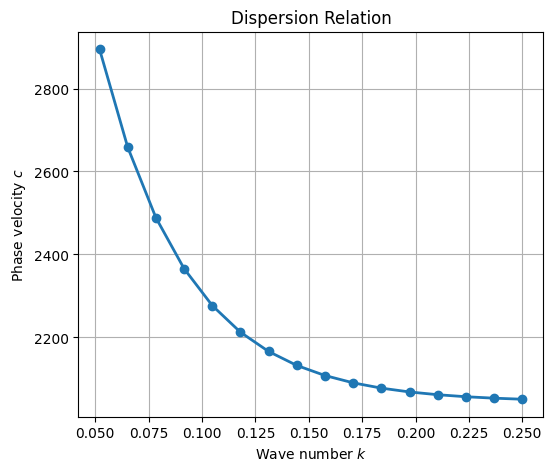

In [17]:
import matplotlib.pyplot as plt
import torch

# dispersion: shape (N, 2) → [k, c]
dispersion = torch.tensor(dispersion)
# dispersion: shape (N, 2) → [k, c]
k_vals = dispersion[:, 0]
c_vals = dispersion[:, 1]


plt.figure(figsize=(6,5))
plt.plot(k_vals, c_vals, 'o-', linewidth=2, markersize=6)

plt.xlabel("Wave number $k$")
plt.ylabel("Phase velocity $c$")
plt.title("Dispersion Relation")
plt.grid(True)

plt.show()



Layer properties:
  μ₄₄ = 3.00e+10 Pa
  ρ = 7500 kg/m³
  c_ref = √(μ₄₄/ρ) = 2000.0 m/s
  H = 2


C:\Users\tdiks\AppData\Local\Temp\ipykernel_23728\734591668.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dispersion = torch.tensor(dispersion)


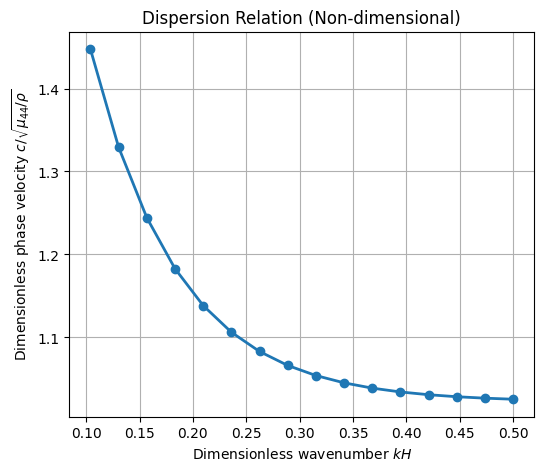


Dispersion data (non-dimensional):
   kH        c/c_ref
   0.104     1.447
   0.130     1.329
   0.157     1.244
   0.183     1.183
   0.210     1.138
   0.236     1.106
   0.262     1.083
   0.289     1.066
   0.315     1.054
   0.342     1.045
   0.368     1.039
   0.394     1.034
   0.421     1.031
   0.447     1.029
   0.474     1.027
   0.500     1.026


In [18]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Your dispersion data
dispersion = torch.tensor(dispersion)
k_vals = dispersion[:, 0]
c_vals = dispersion[:, 1]

# Material properties for layer (from your config)
mu44_layer = 0.3e11 # Pa
rho_layer = 7500.0 # kg/m³
H = 2 # Layer thickness (non-dimensional)

# Calculate reference velocity: √(μ₆₆/ρ) for layer
c_ref_layer = np.sqrt(mu44_layer / rho_layer)# Reference shear speed

print(f"Layer properties:")
print(f"  μ₄₄ = {mu44_layer:.2e} Pa")
print(f"  ρ = {rho_layer:.0f} kg/m³")
print(f"  c_ref = √(μ₄₄/ρ) = {c_ref_layer:.1f} m/s")
print(f"  H = {H}")

# Non-dimensionalize
kH = k_vals * H                     # Dimensionless wavenumber
c_norm = c_vals / c_ref_layer       # Dimensionless phase velocity

# Plot
plt.figure(figsize=(6, 5))
plt.plot(kH, c_norm, 'o-', linewidth=2, markersize=6)

plt.xlabel("Dimensionless wavenumber $kH$")
plt.ylabel("Dimensionless phase velocity $c/\\sqrt{\\mu_{44}/\\rho}$")
plt.title("Dispersion Relation (Non-dimensional)")
plt.grid(True)

plt.show()

# Print the data
print("\nDispersion data (non-dimensional):")
print("   kH        c/c_ref")
for i in range(len(kH)):
    print(f"   {kH[i]:.3f}     {c_norm[i]:.3f}")

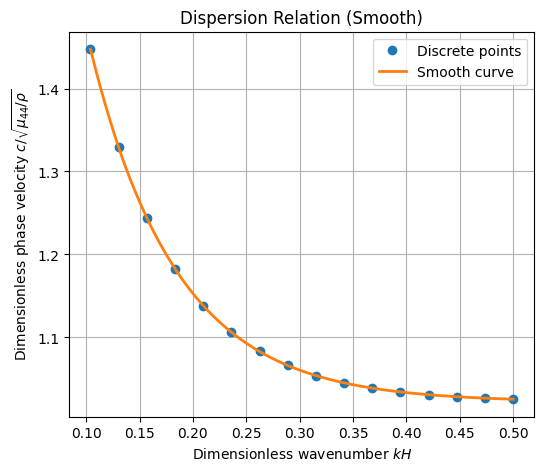

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# If not already done, convert tensors to numpy arrays
kH_np = kH.cpu().numpy() if hasattr(kH, 'cpu') else np.array(kH)
c_norm_np = c_norm.cpu().numpy() if hasattr(c_norm, 'cpu') else np.array(c_norm)

# Sort values for interpolation (required for spline)
sort_idx = np.argsort(kH_np)
kH_sorted = kH_np[sort_idx]
c_norm_sorted = c_norm_np[sort_idx]

# Create smooth curve using cubic spline
kH_smooth = np.linspace(kH_sorted.min(), kH_sorted.max(), 300)
spline = make_interp_spline(kH_sorted, c_norm_sorted, k=2)
c_norm_smooth = spline(kH_smooth)

# Plot both discrete points and smooth curve
plt.figure(figsize=(6, 5))
plt.plot(kH_sorted, c_norm_sorted, 'o', label='Discrete points')
plt.plot(kH_smooth, c_norm_smooth, '-', label='Smooth curve', linewidth=2)
plt.xlabel("Dimensionless wavenumber $kH$")
plt.ylabel("Dimensionless phase velocity $c/\\sqrt{\\mu_{44}/\\rho}$")
plt.title("Dispersion Relation (Smooth)")
plt.grid(True)
plt.legend()
plt.show()

In [20]:
# Save PINN dispersion data
np.savetxt(
    "PINN_dispersion.csv",
    np.column_stack((kH_sorted, c_norm_sorted)),
    delimiter=",",
    header="kH,c_pinn",
    comments=""
)


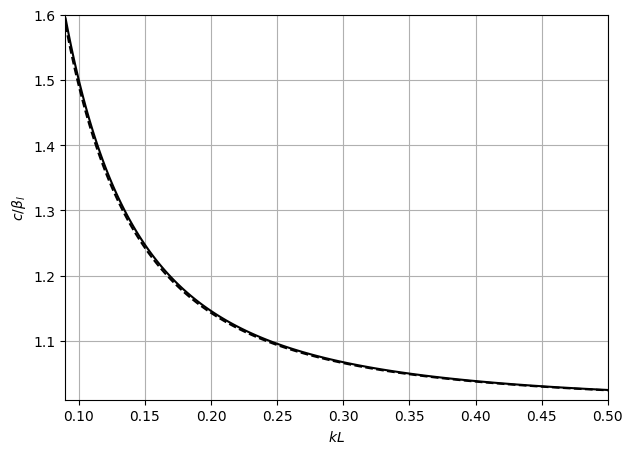

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv, yv
from numpy.lib.scimath import sqrt

# Parameters
rho2 = 2800
rho1 = 7500
L = 2

mu_h = 0.28e11
mu_l = 0.3e11

alpha1 = 0.2
alpha2 = 0.9

s = 100
K = mu_l/(s*L)

P1 = 1e7
P2 = 1e7

beta_l = np.sqrt(mu_l / rho1)
beta_h = np.sqrt(mu_h / rho2)

# Grid (same as MATLAB domain)
x = np.linspace(0.09, 0.5, 400)
y = np.linspace(1.01, 1.6, 400)
X, Y = np.meshgrid(x, y)

# Core expressions
Lambda_l = (X / L)**2 * (Y**2 - 1 - P1 / mu_l)
Lambda_h = sqrt(1 + P2/mu_h - (Y * beta_l / beta_h)**2)

xi0 = sqrt(Lambda_l) / alpha1
xiL = xi0 * (1 - alpha1 * L)

# Bessel
J0_0 = jv(0, xi0)
J1_0 = jv(1, xi0)
Y0_0 = yv(0, xi0)
Y1_0 = yv(1, xi0)

J0_L = jv(0, xiL)
J1_L = jv(1, xiL)
Y0_L = yv(0, xiL)
Y1_L = yv(1, xiL)

# LHS & RHS
denom = (J0_0 * Y1_L - Y0_0 * J1_L)
denom[np.abs(denom) < 1e-10] = np.nan

LHS = (J1_0 * Y1_L - Y1_0 * J1_L) / denom

RHS = (K * mu_h * (alpha2 + (X / L) * Lambda_h)) / (
    mu_l * sqrt(Lambda_l) *
    (mu_h * (alpha2 + (X / L) * Lambda_h) + K)
)

F = np.real(LHS - RHS)

# Plot (exact MATLAB equivalent)
plt.figure(figsize=(7,5))
plt.contour(X, Y, F, levels=[-1e-3, 1e-3], colors='k')
plt.xlabel(r'$kL$')
plt.ylabel(r'$c/\beta_l$')
plt.grid(True)

plt.show()

In [22]:
print(np.min(F), np.max(F))

-0.7756705835776003 0.541822005402023


<Figure size 640x480 with 0 Axes>

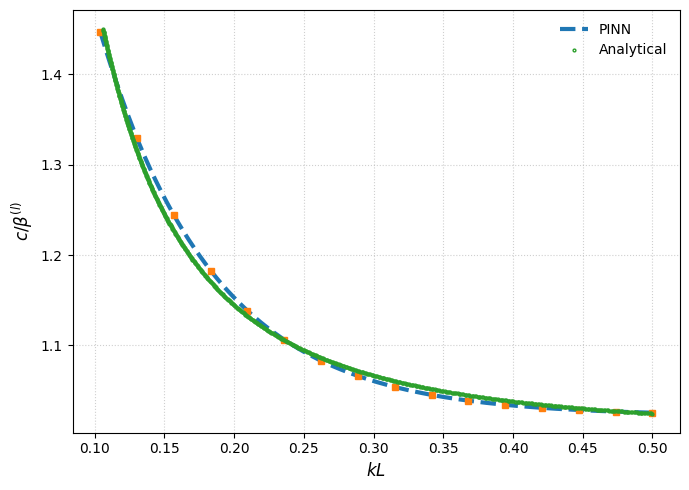

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv, yv
from numpy.lib.scimath import sqrt
from scipy.interpolate import make_interp_spline

# ==============================
# LOAD PINN DATA
# ==============================
pinn = np.loadtxt("PINN_dispersion.csv", delimiter=",", skiprows=1)
kH = pinn[:, 0]
c_pinn = pinn[:, 1]

# ==============================
# PARAMETERS (same as yours)
# ==============================
rho2 = 2800
rho1 = 7500
L = 2

mu_h = 0.28e11
mu_l = 0.3e11

alpha1 = 0.2
alpha2 = 0.9

s = 100
K = mu_l/(s*L)

P1 = 1e7
P2 = 1e7

beta_l = np.sqrt(mu_l / rho1)
beta_h = np.sqrt(mu_h / rho2)

# ==============================
# GRID
# ==============================
x = np.linspace(0.09, 0.5, 400)
y = np.linspace(1.01, 1.45, 400)
X, Y = np.meshgrid(x, y)

# ==============================
# ANALYTICAL FUNCTION
# ==============================
Lambda_l = (X / L)**2 * (Y**2 - 1 - P1 / mu_l)
Lambda_h = sqrt(1 + P2/mu_h - (Y * beta_l / beta_h)**2)

xi0 = sqrt(Lambda_l) / alpha1
xiL = xi0 * (1 - alpha1 * L)

J0_0 = jv(0, xi0)
J1_0 = jv(1, xi0)
Y0_0 = yv(0, xi0)
Y1_0 = yv(1, xi0)

J0_L = jv(0, xiL)
J1_L = jv(1, xiL)
Y0_L = yv(0, xiL)
Y1_L = yv(1, xiL)

denom = (J0_0 * Y1_L - Y0_0 * J1_L)
denom[np.abs(denom) < 1e-10] = np.nan

LHS = (J1_0 * Y1_L - Y1_0 * J1_L) / denom

RHS = (K * mu_h * (alpha2 + (X / L) * Lambda_h)) / (
    mu_l * sqrt(Lambda_l) *
    (mu_h * (alpha2 + (X / L) * Lambda_h) + K)
)

F = np.real(LHS - RHS)

# ==============================
# 🔥 EXTRACT CONTOUR POINTS
# ==============================
cs = plt.contour(X, Y, F, levels=[0])

kH_ana = []
c_ana = []

kH_ana = []
c_ana = []

for seg in cs.allsegs[0]:   # level 0 contour
    kH_ana.extend(seg[:, 0])
    c_ana.extend(seg[:, 1])

        
kH_ana = np.array(kH_ana)
c_ana = np.array(c_ana)

plt.clf()  # clear temporary contour

# ==============================
# SORT analytical
# ==============================
idx = np.argsort(kH_ana)
kH_ana = kH_ana[idx]
c_ana = c_ana[idx]

# ==============================
# SMOOTH PINN
# ==============================
idx_p = np.argsort(kH)
kH_sorted = kH[idx_p]
c_pinn_sorted = c_pinn[idx_p]

kH_smooth = np.linspace(kH_sorted.min(), kH_sorted.max(), 300)
spline = make_interp_spline(kH_sorted, c_pinn_sorted, k=2)
c_pinn_smooth = spline(kH_smooth)

# ==============================
# FINAL PLOT
# ==============================
plt.figure(figsize=(7,5))

# PINN
plt.plot(kH_smooth, c_pinn_smooth, '--', linewidth=3, label='PINN')
plt.plot(kH, c_pinn, 's', markersize=5)

# Analytical
plt.plot(kH_ana, c_ana, 'o',
         markerfacecolor='none',
         markersize=2, label='Analytical')

plt.xlabel(r'$kL$', fontsize=12)
plt.ylabel(r'$c/\beta^{(l)}$', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

In [24]:
# ==========================================================
# SAVE ANALYTICAL DISPERSION CURVE
# ==========================================================

analytical_output = np.column_stack(
    (kH_ana, c_ana)
)

np.savetxt(
    "Analytical_dispersion.csv",
    analytical_output,
    delimiter=",",
    header="kH,c",
    comments=""
)

print("\nSaved: Analytical_dispersion.csv")




Saved: Analytical_dispersion.csv


In [25]:
# ==============================
# ERROR COMPUTATION (CORRECT WAY)
# ==============================

import numpy as np

# ---- Ensure analytical data is sorted ----
idx = np.argsort(kH_ana)
kH_ana = kH_ana[idx]
c_ana = c_ana[idx]

# ---- Interpolate analytical solution onto PINN kH ----
c_ana_interp = np.interp(kH, kH_ana, c_ana)

# ---- Compute errors ----
abs_error = np.abs(c_pinn - c_ana_interp)
rel_error = abs_error / np.abs(c_ana_interp)

# ==============================
# PRINT TABLE
# ==============================
print("\nCOMPARISON TABLE")
print("kH        PINN c/cs   Analytical c/cs   Abs. Error   Rel. Error")

for i in range(len(kH)):
    print(f"{kH[i]:.4f}   {c_pinn[i]:.6f}   {c_ana_interp[i]:.6f}   {abs_error[i]:.3e}   {rel_error[i]:.3e}")

# ==============================
# SAVE CSV (FOR PAPER)
# ==============================
table = np.column_stack((kH, c_pinn, c_ana_interp, abs_error, rel_error))

np.savetxt(
    "comparison_table.csv",
    table,
    delimiter=",",
    header="kH,PINN_c/cs,Analytical_c/cs,Abs_Error,Rel_Error",
    comments=""
)

print("\nSaved: comparison_table.csv")

# ==============================
# ERROR METRICS (IMPORTANT FOR PAPER)
# ==============================
rmse = np.sqrt(np.mean(abs_error**2))
mae = np.mean(abs_error)
max_err = np.max(abs_error)

print("\nError Metrics:")
print(f"RMSE = {rmse:.4e}")
print(f"MAE  = {mae:.4e}")
print(f"Max Error = {max_err:.4e}")


COMPARISON TABLE
kH        PINN c/cs   Analytical c/cs   Abs. Error   Rel. Error
0.1040   1.447344   1.450000   2.656e-03   1.832e-03
0.1304   1.329211   1.314881   1.433e-02   1.090e-02
0.1568   1.244308   1.226484   1.782e-02   1.453e-02
0.1832   1.182900   1.170264   1.264e-02   1.080e-02
0.2096   1.138437   1.132427   6.010e-03   5.307e-03
0.2360   1.106307   1.105817   4.905e-04   4.435e-04
0.2624   1.083063   1.086428   3.365e-03   3.097e-03
0.2888   1.066250   1.071882   5.631e-03   5.254e-03
0.3152   1.054085   1.060701   6.616e-03   6.238e-03
0.3416   1.045280   1.051929   6.649e-03   6.321e-03
0.3680   1.038904   1.044927   6.023e-03   5.764e-03
0.3944   1.034296   1.039247   4.951e-03   4.764e-03
0.4208   1.030958   1.034578   3.620e-03   3.499e-03
0.4472   1.028543   1.030695   2.152e-03   2.088e-03
0.4736   1.026794   1.027432   6.374e-04   6.204e-04
0.5000   1.025534   1.024665   8.692e-04   8.483e-04

Saved: comparison_table.csv

Error Metrics:
RMSE = 7.6519e-03
MAE  = 

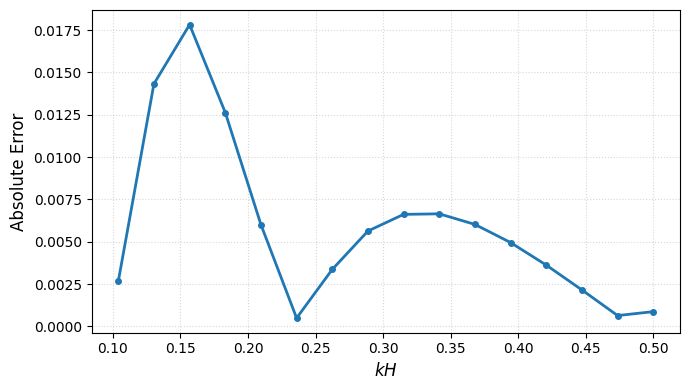

In [26]:
plt.figure(figsize=(7,4))

plt.plot(kH, abs_error, 'o-', linewidth=2, markersize=4)
plt.xlabel(r'$kH$', fontsize=12)
plt.ylabel('Absolute Error', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

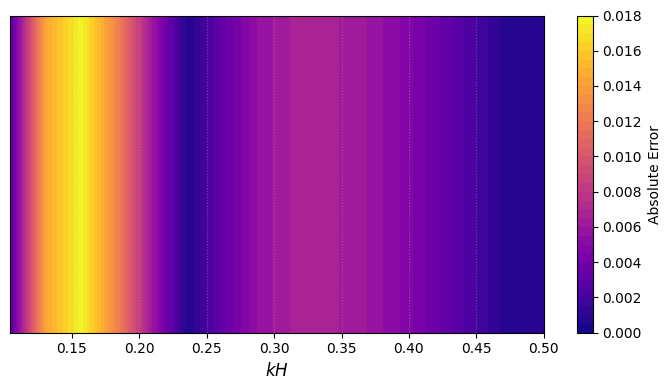

In [27]:
# ==============================
# Absolute error contour (fixed)
# ==============================

# artificial vertical axis
y = np.linspace(0, 1, 50)

# create meshgrid using PINN kH
KH, Y = np.meshgrid(kH, y)

# repeat error along vertical direction
Z = np.tile(abs_error, (len(y), 1))

# ==============================
# PLOT
# ==============================
plt.figure(figsize=(7,4))

cont = plt.contourf(KH, Y, Z, levels=40, cmap='plasma')
cbar = plt.colorbar(cont)
cbar.set_label('Absolute Error')

plt.xlabel(r'$kH$', fontsize=12)
plt.ylabel('', fontsize=10)
plt.yticks([])

plt.xlim([min(kH), max(kH)])
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

In [28]:
# ==============================
# PREPARE CORRECT ARRAYS
# ==============================
# ensure analytical is sorted
idx = np.argsort(kH_ana)
kH_ana = kH_ana[idx]
c_ana = c_ana[idx]

# interpolate analytical onto PINN kH
c_ana_interp = np.interp(kH, kH_ana, c_ana)

pred = np.asarray(c_pinn).flatten()
true = np.asarray(c_ana_interp).flatten()

# ==============================
# ERROR COMPUTATION
# ==============================
err = pred - true
abs_err = np.abs(err)

L1   = np.mean(abs_err)
RMSE = np.sqrt(np.mean(err**2))
L2   = np.sqrt(np.sum(err**2))
Linf = np.max(abs_err)
relL2 = L2 / np.sqrt(np.sum(true**2))

labels = ['L1', 'RMSE', 'L2 norm', 'L∞', 'Rel L2']
values = [L1, RMSE, L2, Linf, relL2]

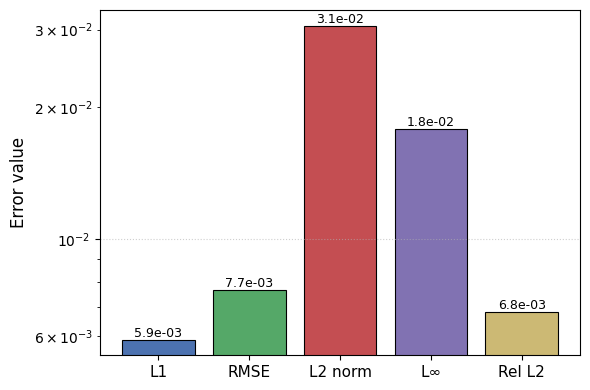

In [29]:
plt.figure(figsize=(6,4))

colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']
bars = plt.bar(labels, values, color=colors, edgecolor='black', linewidth=0.8)

plt.yscale('log')
plt.ylabel('Error value', fontsize=12)

# value labels (avoid overlap in log scale)
for b in bars:
    h = b.get_height()
    plt.text(b.get_x()+b.get_width()/2, h*1,
             f'{h:.1e}',
             ha='center', va='bottom', fontsize=9)

plt.grid(True, linestyle=':', axis='y', alpha=0.6)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.show()



TRAINING RESULTS
       Activation  Depth  Width    Final_Loss     c(k=0.1)    c(k=0.15)  \
0            tanh      3     20  4.998058e-08  2278.320312  2133.044922   
1         sigmoid      3     20  3.604250e-08  2266.508789  2129.184326   
2            relu      3     20  1.140920e-06  2279.972412  2132.924072   
3            gelu      3     20  2.361248e-08  2277.420898  2132.691406   
4            silu      3     20  3.536496e-08  2272.014893  2130.390381   
5        softplus      3     20  2.492714e-07  2283.683350  2135.430420   
6             sin      3     20  1.515868e-07  2276.901611  2132.485352   
7          arctan      3     20  1.694895e-08  2277.966064  2132.840576   
8        sin_tanh      3     20  4.500327e-08  2276.887451  2132.525146   
9        sin_gelu      3     20  2.439690e-08  2279.912842  2133.702148   
10  sin_tanh_gelu      3     20  2.210323e-08  2276.874023  2132.500244   

       c(k=0.2)    c(k=0.25)  
0   2068.732422  2051.100098  
1   2067.770020  2

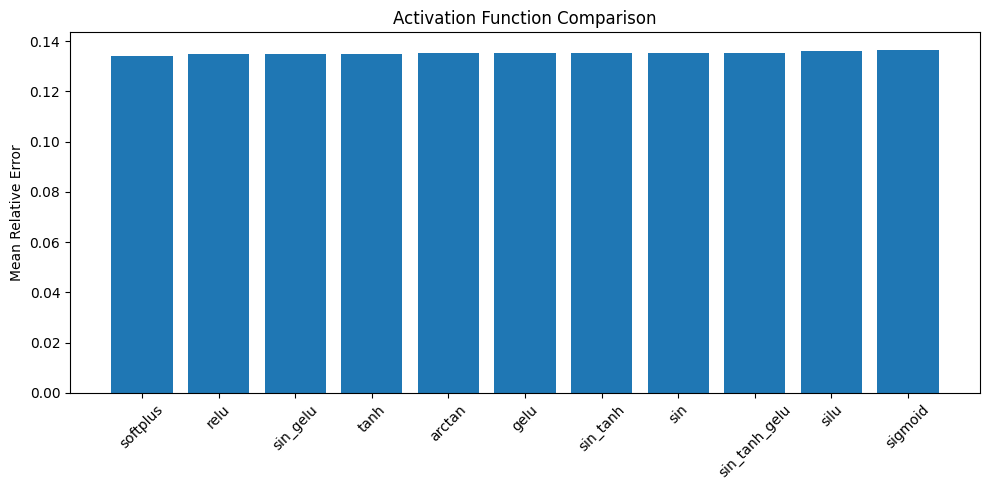

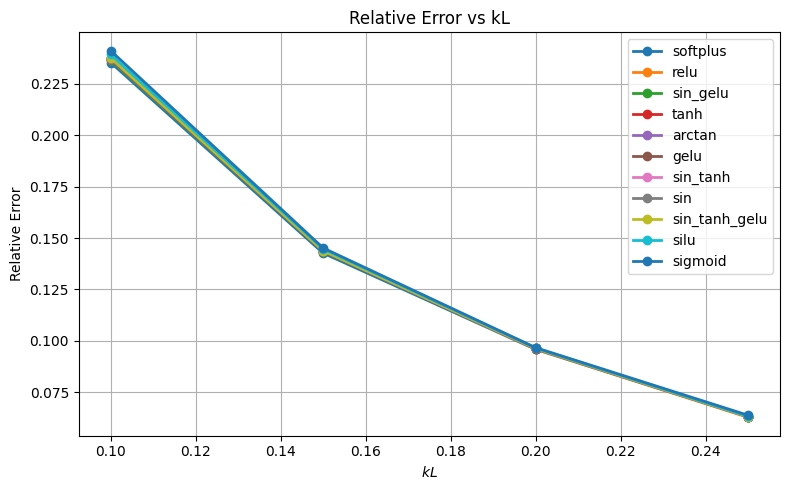

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d


# =========================================================
# LOAD ANALYTICAL DISPERSION
# =========================================================

ana = np.loadtxt(

    "Analytical_dispersion.csv",

    delimiter=",",

    skiprows=1

)

kH_ana = ana[:,0]

c_ana  = ana[:,1]


# =========================================================
# SORT ANALYTICAL DATA
# =========================================================

idx = np.argsort(kH_ana)

kH_ana = kH_ana[idx]

c_ana  = c_ana[idx]


# =========================================================
# INTERPOLATION FUNCTION
# =========================================================

f_ana = interp1d(

    kH_ana,
    c_ana,

    bounds_error=False,

    fill_value="extrapolate"

)


# =========================================================
# LOAD TRAINING SUMMARY
# =========================================================

df_train = pd.read_csv(

    "architecture_study.csv"

)

print("\n")
print("="*120)
print("TRAINING RESULTS")
print("="*120)

print(df_train)


# =========================================================
# SPECIFIC k VALUES
# =========================================================

k_targets = [

    0.10,
    0.15,
    0.20,
    0.25

]


# =========================================================
# ANALYTICAL VALUES
# =========================================================

analytical_values = {}

for k in k_targets:

    analytical_values[k] = float(f_ana(k))


print("\n")
print("="*80)
print("ANALYTICAL VALUES")
print("="*80)

for k, val in analytical_values.items():

    print(

        f"k = {k:.2f}"
        f" --> "
        f"c = {val:.6f}"

    )


# =========================================================
# ERROR ANALYSIS
# =========================================================

error_results = []

for idx_row in range(len(df_train)):

    row = df_train.iloc[idx_row]

    activation = row["Activation"]

    result = {

        "Activation": activation

    }

    errors = []


    # -----------------------------------------------------
    # k-wise error
    # -----------------------------------------------------

    for k in k_targets:

       
        c_pinn_dim = row[f"c(k={k})"]

# nondimensionalize
        c_pinn = c_pinn_dim / beta_l

        c_exact = analytical_values[k]

        rel_error = abs(

            c_pinn - c_exact

        ) / abs(c_exact)

        errors.append(rel_error)

        result[f"Error(k={k})"] = rel_error


    # -----------------------------------------------------
    # statistics
    # -----------------------------------------------------

    result["Mean_Error"] = np.mean(errors)

    result["Max_Error"]  = np.max(errors)

    result["Final_Loss"] = row["Final_Loss"]

    error_results.append(result)


# =========================================================
# FINAL ERROR TABLE
# =========================================================

df_error = pd.DataFrame(error_results)

df_error = df_error.sort_values(

    by="Mean_Error"

)


print("\n")
print("="*140)
print("ACTIVATION FUNCTION ERROR ANALYSIS")
print("="*140)

print(df_error)


# =========================================================
# SAVE CSV
# =========================================================

df_error.to_csv(

    "activation_error_analysis.csv",

    index=False

)

print("\nSaved : activation_error_analysis.csv")


# =========================================================
# BAR PLOT
# =========================================================

plt.figure(figsize=(10,5))

plt.bar(

    df_error["Activation"],
    df_error["Mean_Error"]

)

plt.xticks(rotation=45)

plt.ylabel("Mean Relative Error")

plt.title("Activation Function Comparison")

plt.tight_layout()

plt.savefig(

    "Activation_Error_Comparison.png",

    dpi=300

)

plt.show()


# =========================================================
# ERROR vs k
# =========================================================

plt.figure(figsize=(8,5))

for idx_row in range(len(df_error)):

    row = df_error.iloc[idx_row]

    activation = row["Activation"]

    err_values = [

        row["Error(k=0.1)"],
        row["Error(k=0.15)"],
        row["Error(k=0.2)"],
        row["Error(k=0.25)"]

    ]

    plt.plot(

        k_targets,
        err_values,

        marker='o',

        linewidth=2,

        label=activation

    )

plt.xlabel(r"$kL$")

plt.ylabel("Relative Error")

plt.title("Relative Error vs kL")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(

    "Error_vs_k.png",

    dpi=300

)

plt.show()